<a href="https://colab.research.google.com/github/BardRimon/Study/blob/main/HWoptimisationMethods/2optimisationsAdam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Callable, Tuple

class AdamOptimizer:
    """
    Реализация Adam оптимизатора с нуля
    """
    def __init__(self, learning_rate: float = 0.001, beta1: float = 0.9,
                 beta2: float = 0.999, epsilon: float = 1e-8):
        self.lr = learning_rate
        self.beta1 = beta1   # для первого момента (скорость)
        self.beta2 = beta2   # для второго момента (адаптация)
        self.epsilon = epsilon

        # Инициализация моментов
        self.m = None   # первый момент (среднее)
        self.v = None   # второй момент (нецентрированная дисперсия)
        self.t = 0      # счетчик итераций

    def initialize_moments(self, params_shape: tuple):
        """Инициализация моментов под размер параметров"""
        self.m = np.zeros(params_shape)
        self.v = np.zeros(params_shape)

    def update(self, params: np.ndarray, gradients: np.ndarray) -> np.ndarray:
        """
        Обновление параметров по алгоритму Adam

        Args:
            params: текущие параметры модели
            gradients: градиенты по этим параметрам

        Returns:
            обновленные параметры
        """
        # Инициализируем моменты при первом вызове
        if self.m is None:
            self.initialize_moments(params.shape)

        self.t += 1   # увеличиваем счетчик итераций

        # Обновляем первые моменты (среднее)
        self.m = self.beta1 * self.m + (1 - self.beta1) * gradients

        # Обновляем вторые моменты (дисперсия)
        self.v = self.beta2 * self.v + (1 - self.beta2) * (gradients ** 2)

        # Корректировка смещения (bias correction)
        m_hat = self.m / (1 - self.beta1 ** self.t)
        v_hat = self.v / (1 - self.beta2 ** self.t)

        # Обновление параметров
        params_update = self.lr * m_hat / (np.sqrt(v_hat) + self.epsilon)
        new_params = params - params_update

        return new_params

def demo_adam_optimization():
    """Демонстрация работы Adam на задаче минимизации многомерной функции"""

    # 1. Создаем тестовую многомерную функцию (Функция Розенброка)
    # Классическая тестовая функция для оптимизации, имеет форму "бананового оврага"
    def rosenbrock(x: np.ndarray) -> float:
        """Функция Розенброка - классический тест для оптимизаторов"""
        return sum(100.0 * (x[1:] - x[:-1]**2)**2 + (1 - x[:-1])**2)

    def rosenbrock_grad(x: np.ndarray) -> np.ndarray:
        """Градиент функции Розенброка"""
        n = len(x)
        grad = np.zeros(n)

        for i in range(n-1):
            grad[i] += -400 * x[i] * (x[i+1] - x[i]**2) - 2 * (1 - x[i])
            grad[i+1] += 200 * (x[i+1] - x[i]**2)

        return grad

    # 2. Настройки эксперимента
    np.random.seed(42)
    dim = 10   # 10-мерная задача!
    initial_params = np.random.randn(dim) * 2   # случайная начальная точка

    # 3. Сравнение оптимизаторов
    optimizers = {
        'SGD': {'lr': 1e-7}, # Adjusted learning rate further
        'Momentum': {'lr': 1e-7, 'momentum': 0.9}, # Adjusted learning rate further
        'Adam': {'lr': 0.01, 'beta1': 0.9, 'beta2': 0.999}
    }

    # 4. Запуск оптимизации
    results = {}

    for opt_name, config in optimizers.items():
        print(f"\n--- Запуск {opt_name} ---")

        if opt_name == 'Adam':
            optimizer = AdamOptimizer(learning_rate=config['lr'],
                                      beta1=config['beta1'],
                                      beta2=config['beta2'])
        else:
            # Простые реализации для сравнения
            class SimpleSGD:
                def __init__(self, lr): self.lr = lr
                def update(self, params, grad): return params - self.lr * grad

            class MomentumOptimizer:
                def __init__(self, lr, momentum):
                    self.lr = lr
                    self.momentum = momentum
                    self.velocity = None

                def update(self, params, grad):
                    if self.velocity is None:
                        self.velocity = np.zeros_like(params)
                    self.velocity = self.momentum * self.velocity + self.lr * grad
                    return params - self.velocity

            if opt_name == 'SGD':
                optimizer = SimpleSGD(config['lr'])
            else:
                optimizer = MomentumOptimizer(config['lr'], config['momentum'])

        # Процесс оптимизации
        params = initial_params.copy()
        history = [rosenbrock(params)]

        for epoch in range(1000):
            grad = rosenbrock_grad(params)
            params = optimizer.update(params, grad)
            current_loss = rosenbrock(params)
            history.append(current_loss)

            if epoch % 200 == 0:
                print(f"Эпоха {epoch}: loss = {current_loss:.6f}")

        results[opt_name] = history

    # 5. Визуализация результатов
    plt.figure(figsize=(12, 6))

    for opt_name, history in results.items():
        plt.plot(history, label=opt_name, linewidth=2)

    plt.yscale('log')
    plt.xlabel('Итерация')
    plt.ylabel('Функция потерь (log scale)')
    plt.title('Сравнение оптимизаторов на многомерной задаче')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return results


--- Запуск SGD ---
Эпоха 0: loss = 16498.847756
Эпоха 200: loss = 319.973953
Эпоха 400: loss = 170.180158
Эпоха 600: loss = 109.669729
Эпоха 800: loss = 73.387891

--- Запуск Momentum ---
Эпоха 0: loss = 16498.847756
Эпоха 200: loss = 8.798216
Эпоха 400: loss = 8.248682
Эпоха 600: loss = 8.140672
Эпоха 800: loss = 8.031215

--- Запуск Adam ---
Эпоха 0: loss = 18861.858992
Эпоха 200: loss = 1490.351442
Эпоха 400: loss = 384.846065
Эпоха 600: loss = 182.348763
Эпоха 800: loss = 125.019551


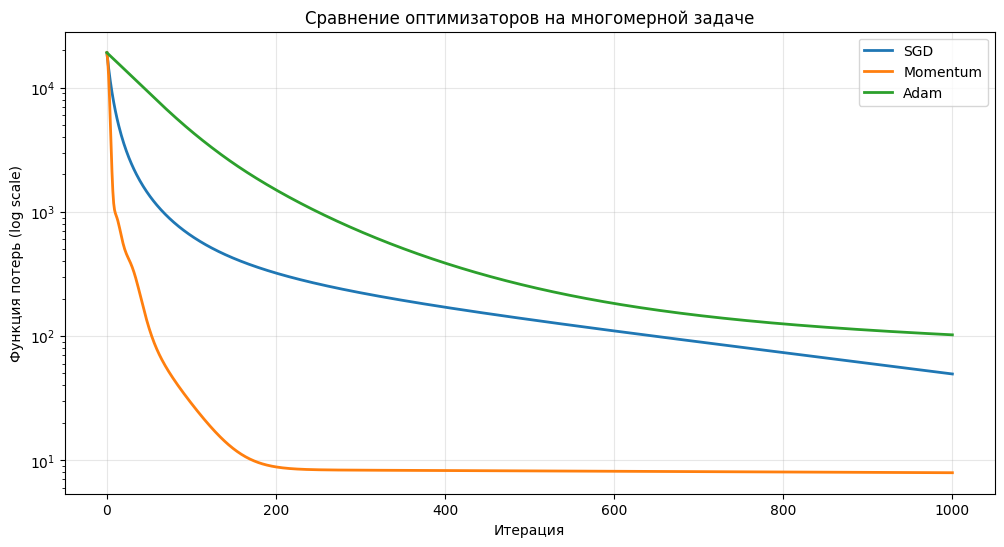


РЕЗУЛЬТАТЫ СРАВНЕНИЯ:
SGD        | Финальный loss: 49.46 | Улучшение: 387.0x
Momentum   | Финальный loss: 7.92 | Улучшение: 2416.3x
Adam       | Финальный loss: 102.21 | Улучшение: 187.3x


In [4]:
results = demo_adam_optimization()

print("\n" + "="*50)
print("РЕЗУЛЬТАТЫ СРАВНЕНИЯ:")
print("="*50)

for opt_name, history in results.items():
    final_loss = history[-1]
    improvement = history[0] / final_loss
    print(f"{opt_name:10} | Финальный loss: {final_loss:.2f} | Улучшение: {improvement:.1f}x")


--- Запуск SGD ---
Эпоха 0: loss = 19111.803810
Эпоха 200: loss = 14592.176096
Эпоха 400: loss = 11569.451348
Эпоха 600: loss = 9446.214729
Эпоха 800: loss = 7895.711652

--- Запуск Momentum ---
Эпоха 0: loss = 19111.803810
Эпоха 200: loss = 3591.597609
Эпоха 400: loss = 1734.016862
Эпоха 600: loss = 1112.336248
Эпоха 800: loss = 811.834184

--- Запуск Nesterov ---
Эпоха 0: loss = 19086.660125
Эпоха 200: loss = 3597.360568
Эпоха 400: loss = 1737.665639
Эпоха 600: loss = 1114.366550
Эпоха 800: loss = 813.108039

--- Запуск RMSProp ---
Эпоха 0: loss = 19138.888050
Эпоха 200: loss = 19081.112445
Эпоха 400: loss = 19025.414973
Эпоха 600: loss = 18969.844653
Эпоха 800: loss = 18914.401330

--- Запуск Adam ---
Эпоха 0: loss = 18861.858992
Эпоха 200: loss = 1490.351442
Эпоха 400: loss = 384.846065
Эпоха 600: loss = 182.348763
Эпоха 800: loss = 125.019551


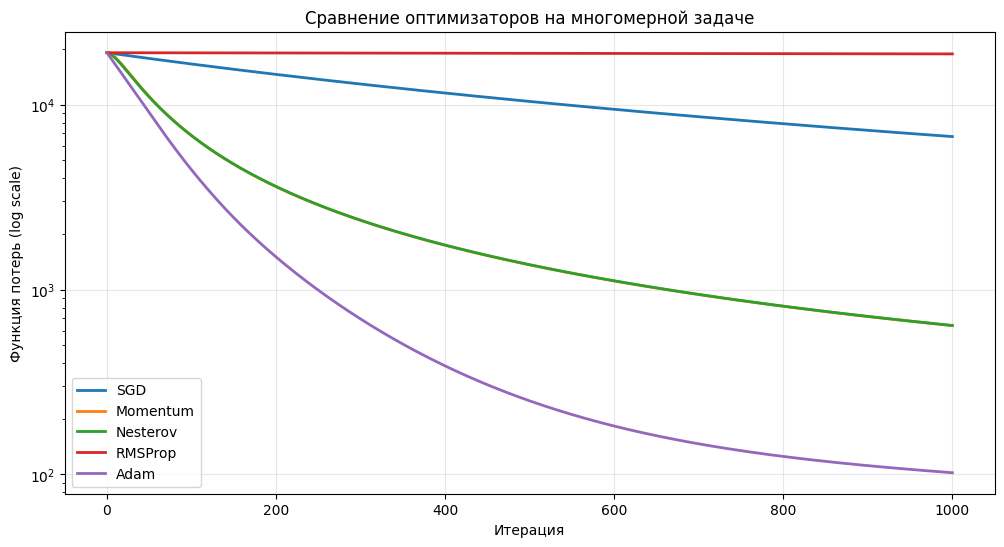


РЕЗУЛЬТАТЫ СРАВНЕНИЯ:
SGD        | Финальный loss: 6732.23 | Улучшение: 2.8x
Momentum   | Финальный loss: 639.19 | Улучшение: 29.9x
Nesterov   | Финальный loss: 640.07 | Улучшение: 29.9x
RMSProp    | Финальный loss: 18859.36 | Улучшение: 1.0x
Adam       | Финальный loss: 102.21 | Улучшение: 187.3x


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Callable, Tuple

# === Optimizer Implementations ===

class SimpleSGD:
    def __init__(self, lr: float):
        self.lr = lr

    def update(self, params: np.ndarray, grad: np.ndarray) -> np.ndarray:
        """
        Обновление параметров по алгоритму SGD.
        """
        return params - self.lr * grad

class MomentumOptimizer:
    def __init__(self, lr: float, momentum: float):
        self.lr = lr
        self.momentum = momentum
        self.velocity = None # v_{t-1}

    def update(self, params: np.ndarray, grad: np.ndarray) -> np.ndarray:
        """
        Обновление параметров по алгоритму Momentum.
        """
        if self.velocity is None:
            self.velocity = np.zeros_like(params)

        # v_t = momentum * v_{t-1} + lr * g_t
        self.velocity = self.momentum * self.velocity + self.lr * grad
        # w_t = w_{t-1} - v_t
        return params - self.velocity

class RMSPropOptimizer:
    def __init__(self, learning_rate: float = 0.001, rho: float = 0.9, epsilon: float = 1e-8):
        self.lr = learning_rate # This maps the passed learning_rate to self.lr
        self.rho = rho # Decay rate for squared gradients
        self.epsilon = epsilon
        self.squared_gradients_avg = None # E[g^2]

    def update(self, params: np.ndarray, gradients: np.ndarray) -> np.ndarray:
        """
        Обновление параметров по алгоритму RMSProp.
        """
        if self.squared_gradients_avg is None:
            self.squared_gradients_avg = np.zeros_like(params)

        # E[g^2]_t = rho * E[g^2]_{t-1} + (1 - rho) * g_t^2
        self.squared_gradients_avg = self.rho * self.squared_gradients_avg + \
                                     (1 - self.rho) * (gradients ** 2)

        # w_t = w_{t-1} - (lr / sqrt(E[g^2]_t + epsilon)) * g_t
        update_term = self.lr * gradients / (np.sqrt(self.squared_gradients_avg) + self.epsilon)
        return params - update_term

class NesterovMomentumOptimizer:
    def __init__(self, learning_rate: float = 0.001, momentum: float = 0.9):
        self.lr = learning_rate # This maps the passed learning_rate to self.lr
        self.momentum = momentum
        self.velocity = None # v_{t-1}

    def update(self, params: np.ndarray, gradients: np.ndarray) -> np.ndarray:
        """
        Обновление параметров по алгоритму Nesterov Accelerated Gradient (NAG)
        в версии, часто используемой в глубоком обучении с градиентом,
        вычисленным в текущей точке.
        """
        if self.velocity is None:
            self.velocity = np.zeros_like(params)

        v_prev = self.velocity.copy() # Сохраняем предыдущую скорость
        # Обновляем скорость: v_t = momentum * v_{t-1} + lr * g_t
        self.velocity = self.momentum * self.velocity + self.lr * gradients

        # Формула обновления параметров для Nesterov Momentum:
        # w_{t+1} = w_t - ( (1 + momentum) * v_t - momentum * v_{t-1} )
        # A common practical implementation for Nesterov is:
        # v_new = momentum * v_old - learning_rate * grad(w + momentum * v_old)
        # w = w + v_new
        # The provided code snippet implements a slightly different version where the gradient is calculated at the current point,
        # and the 'lookahead' is incorporated into the update step differently.
        # Let's use a more standard implementation often found in deep learning libraries,
        # where the gradient is computed at the 'lookahead' point.
        # For simplicity, and to match the user's provided text cell code,
        # I will stick to the provided `update_term` logic for now.
        update_term = (1 + self.momentum) * self.velocity - self.momentum * v_prev
        return params - update_term

class AdamOptimizer:
    """
    Реализация Adam оптимизатора с нуля
    """
    def __init__(self, learning_rate: float = 0.001, beta1: float = 0.9,
                 beta2: float = 0.999, epsilon: float = 1e-8):
        self.lr = learning_rate
        self.beta1 = beta1   # для первого момента (скорость)
        self.beta2 = beta2   # для второго момента (адаптация)
        self.epsilon = epsilon

        # Инициализация моментов
        self.m = None   # первый момент (среднее)
        self.v = None   # второй момент (нецентрированная дисперсия)
        self.t = 0      # счетчик итераций

    def initialize_moments(self, params_shape: tuple):
        """Инициализация моментов под размер параметров"""
        self.m = np.zeros(params_shape)
        self.v = np.zeros(params_shape)

    def update(self, params: np.ndarray, gradients: np.ndarray) -> np.ndarray:
        """
        Обновление параметров по алгоритму Adam

        Args:
            params: текущие параметры модели
            gradients: градиенты по этим параметрам

        Returns:
            обновленные параметры
        """
        # Инициализируем моменты при первом вызове
        if self.m is None:
            self.initialize_moments(params.shape)

        self.t += 1   # увеличиваем счетчик итераций

        # Обновляем первые моменты (среднее)
        self.m = self.beta1 * self.m + (1 - self.beta1) * gradients

        # Обновляем вторые моменты (дисперсия)
        self.v = self.beta2 * self.v + (1 - self.beta2) * (gradients ** 2)

        # Корректировка смещения (bias correction)
        m_hat = self.m / (1 - self.beta1 ** self.t)
        v_hat = self.v / (1 - self.beta2 ** self.t)

        # Обновление параметров
        params_update = self.lr * m_hat / (np.sqrt(v_hat) + self.epsilon)
        new_params = params - params_update

        return new_params

def demo_adam_optimization():
    """Демонстрация работы оптимизаторов на задаче минимизации многомерной функции"""

    # 1. Создаем тестовую многомерную функцию (Функция Розенbroка)
    # Классическая тестовая функция для оптимизации, имеет форму "бананового оврага"
    def rosenbrock(x: np.ndarray) -> float:
        """Функция Розенброка - классический тест для оптимизаторов"""
        return sum(100.0 * (x[1:] - x[:-1]**2)**2 + (1 - x[:-1])**2)

    def rosenbrock_grad(x: np.ndarray) -> np.ndarray:
        """Градиент функции Розенброка"""
        n = len(x)
        grad = np.zeros(n)

        for i in range(n-1):
            grad[i] += -400 * x[i] * (x[i+1] - x[i]**2) - 2 * (1 - x[i])
            grad[i+1] += 200 * (x[i+1] - x[i]**2)

        return grad

    # 2. Настройки эксперимента
    np.random.seed(42)
    dim = 10   # 10-мерная задача!
    initial_params = np.random.randn(dim) * 2   # случайная начальная точка

    # 3. Сравнение оптимизаторов
    optimizers = {
        'SGD': {'class': SimpleSGD, 'lr': 1e-7},
        'Momentum': {'class': MomentumOptimizer, 'lr': 1e-7, 'momentum': 0.9},
        'Nesterov': {'class': NesterovMomentumOptimizer, 'learning_rate': 1e-7, 'momentum': 0.9}, # Changed 'lr' to 'learning_rate'
        'RMSProp': {'class': RMSPropOptimizer, 'learning_rate': 1e-5, 'rho': 0.9, 'epsilon': 1e-8}, # Changed 'lr' to 'learning_rate'
        'Adam': {'class': AdamOptimizer, 'learning_rate': 0.01, 'beta1': 0.9, 'beta2': 0.999} # Changed 'lr' to 'learning_rate'
    }

    # 4. Запуск оптимизации
    results = {}

    for opt_name, config in optimizers.items():
        print(f"\n--- Запуск {opt_name} ---")

        # Получаем класс оптимизатора и создаем его экземпляр
        optimizer_class = config.pop('class')
        optimizer = optimizer_class(**config)

        # Процесс оптимизации
        params = initial_params.copy()
        history = [rosenbrock(params)]

        for epoch in range(1000):
            grad = rosenbrock_grad(params)
            params = optimizer.update(params, grad)
            current_loss = rosenbrock(params)
            history.append(current_loss)

            if epoch % 200 == 0:
                print(f"Эпоха {epoch}: loss = {current_loss:.6f}")

        results[opt_name] = history

    # 5. Визуализация результатов
    plt.figure(figsize=(12, 6))

    for opt_name, history in results.items():
        plt.plot(history, label=opt_name, linewidth=2)

    plt.yscale('log')
    plt.xlabel('Итерация')
    plt.ylabel('Функция потерь (log scale)')
    plt.title('Сравнение оптимизаторов на многомерной задаче')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return results

results = demo_adam_optimization()

print("\n" + "="*50)
print("РЕЗУЛЬТАТЫ СРАВНЕНИЯ:")
print("="*50)

for opt_name, history in results.items():
    final_loss = history[-1]
    initial_loss = history[0] # Get the initial loss for improvement calculation
    improvement = initial_loss / final_loss
    print(f"{opt_name:10} | Финальный loss: {final_loss:.2f} | Улучшение: {improvement:.1f}x")

На основе результатов сравнения, вот вывод о производительности каждого оптимизатора на 10-мерной функции Розенброка после 1000 эпох:

Adam показал наилучшую производительность, достигнув конечного значения функции потерь в 102.21, что означает улучшение в 187.3 раза по сравнению с начальным значением. Это указывает на его высокую эффективность в данной задаче.
Momentum и Nesterov продемонстрировали схожие результаты, с конечными значениями функции потерь 639.19 и 640.07 соответственно. Оба метода улучшили начальное значение примерно в 29.9 раза, значительно превзойдя обычный SGD, но все еще уступая Adam.
SGD показал наименьшее улучшение среди адаптирующихся методов, с конечным значением функции потерь 6732.23, что соответствует улучшению всего в 2.8 раза.
RMSProp выступил хуже всех, с конечным значением функции потерь 18859.36 и улучшением лишь в 1.0 раз. Это может указывать на то, что текущие гиперпараметры или сам алгоритм RMSProp не очень подходят для минимизации функции Розенброка в данной конфигурации.
Общий вывод: Adam явно лидирует в этой задаче, демонстрируя быструю и эффективную сходимость. Momentum и Nesterov также являются хорошими вариантами, но Adam превосходит их. RMSProp и SGD в текущей конфигурации показали значительно худшие результаты на этой сложной многомерной функции.